In [1]:
from _setup import setup_project_root
PROJECT_ROOT = setup_project_root()

In [2]:
import importlib
import pandas as pd
import joblib
import evaluation.metrics as metrics
from models.XGBoost import XGBoostBaseConfig, build_xy, fit_model, predict

In [6]:
train_path = PROJECT_ROOT / "data" / "station_split" / "train.csv"
val_path   = PROJECT_ROOT / "data" / "station_split" / "val.csv"
test_path  = PROJECT_ROOT / "data" / "station_split" / "test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

In [7]:
pm25_scaler = joblib.load(PROJECT_ROOT / "artifacts" / "pm25_scaler.pkl")

c:\Users\KimNgan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
config = XGBoostBaseConfig(
    time_col="date", 
    lags=24, 
    horizon=24,
    xgb_params={
        "n_estimators": 500,
        "max_depth": 9,
        "tree_method": "hist",
        "learning_rate": 0.05,
        "random_state": 42
    }
)

In [16]:
X_train, y_train = build_xy(train_df, config, extra_feature_cols=["Station_No"])
X_test, y_test = build_xy(test_df, config, extra_feature_cols=["Station_No"])

In [17]:
model_global = fit_model(X_train, y_train, config)
pred_test = predict(model_global, X_test)
res = metrics.compute_metrics_real_scale(y_test, pred_test, scaler=pm25_scaler)
print("Global XGBoost Results:", res)

Global XGBoost Results: {'Correlation': 0.4095356025291093, 'RMSE': 64.19620333608597, 'MAPE': 0.46973198132566574, 'MAE': 47.24077362982967}


Plot

In [18]:
%load_ext autoreload
%autoreload 2

from evaluation.plots import (
    plot_actual_vs_pred,
    plot_scatter_actual_pred,
    plot_residuals_vs_pred,
    plot_error_distribution,
    plot_actual_vs_pred_by_station,
)


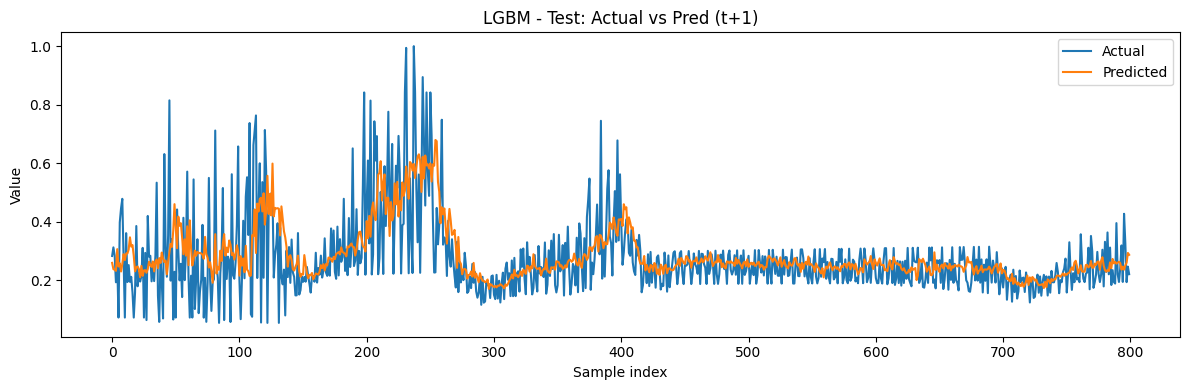

In [ ]:
plot_actual_vs_pred(
    y_test, pred_test,
    title="XGBoost - Test: Actual vs Pred (t+1)",
    horizon=0,
    n_points=800
)

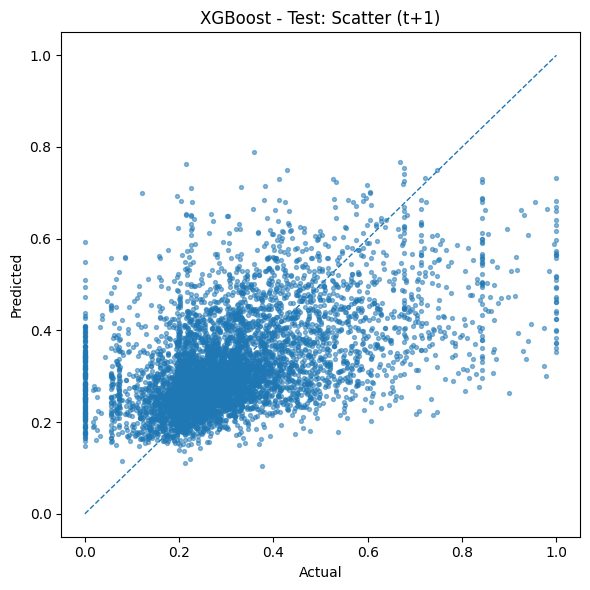

In [22]:
plot_scatter_actual_pred(
    y_test, pred_test,
    title="XGBoost - Test: Scatter (t+1)",
    horizon=0,
    sample=6000
)

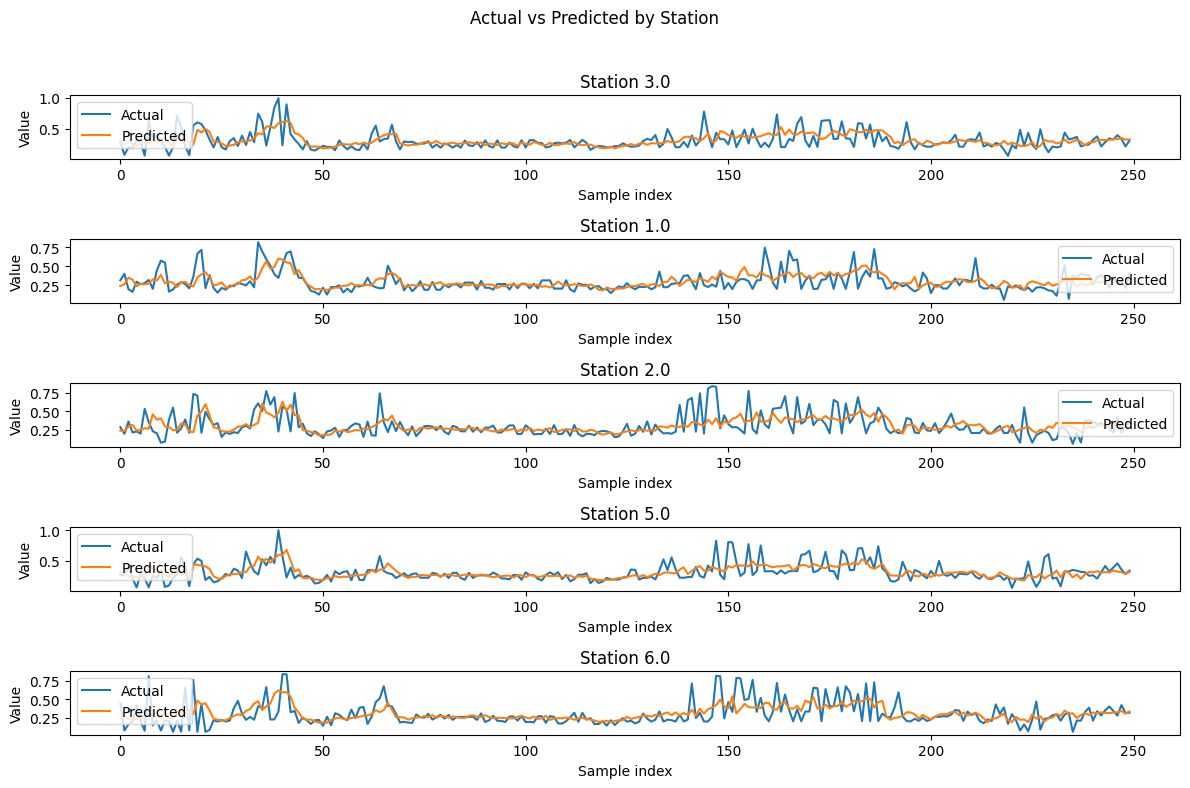

In [21]:
station_ids_aligned = test_df.loc[X_test.index, "Station_No"].to_numpy()
plot_actual_vs_pred_by_station(
    station_ids=station_ids_aligned,
    y_true=y_test,
    y_pred=pred_test,
    horizon=0,
    n_points_per_station=250,
    max_stations=5
)